Question 1. Given a synthetic 1D dataset generated from two Gaussian distributions with
unknown means 𝜇1, 𝜇2, unknown variances 𝜎1^2, 𝜎2^2, and mixing proportions 𝜋1, 𝜋2:
1) Write a Python function to perform the E-step: Calculate the responsibilities 𝛾(𝑧𝑛𝑘)
2) for each data point.
3) Write a function for the M-step: Update the parameters (𝜇𝑘, 𝜎𝑘2, 𝜋𝑘) based on the responsibilities.
4) Iterate until the log-likelihood converges.
5) Plot the histogram of the data and overlay the evolved Gaussian PDF curves at iterations 1, 5, and 20.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Two Gaussians
data1 = np.random.normal(loc=-2, scale=0.5, size=200)
data2 = np.random.normal(loc=2, scale=1.0, size=300)

X = np.concatenate([data1, data2])

In [49]:
K = 2
mu = np.random.choice(X, K)
sigma2 = np.ones(K)
pi = np.ones(K) / K

In [22]:
def e_step(X, mu, sigma2, pi):
    N = len(X)
    K = len(mu)
    gamma = np.zeros((N, K))

    for k in range(K):
        gamma[:, k] = pi[k] * norm.pdf(X, mu[k], np.sqrt(sigma2[k]))

    gamma /= gamma.sum(axis=1, keepdims=True)
    return gamma

In [23]:
def m_step(X, gamma):
    N, K = gamma.shape

    Nk = gamma.sum(axis=0)

    mu = (gamma * X[:, None]).sum(axis=0) / Nk
    sigma2 = ((gamma * (X[:, None] - mu)**2).sum(axis=0)) / Nk
    pi = Nk / N

    return mu, sigma2, pi

In [24]:
def log_likelihood(X, mu, sigma2, pi):
    total = 0
    for x in X:
        s = 0
        for k in range(len(mu)):
            s += pi[k] * norm.pdf(x, mu[k], np.sqrt(sigma2[k]))
        total += np.log(s)
    return total

In [25]:
iterations = [1, 5, 20]
stored_params = {}

for i in range(20):
    gamma = e_step(X, mu, sigma2, pi)
    mu, sigma2, pi = m_step(X, gamma)

    if i+1 in iterations:
        stored_params[i+1] = (mu.copy(), sigma2.copy(), pi.copy())

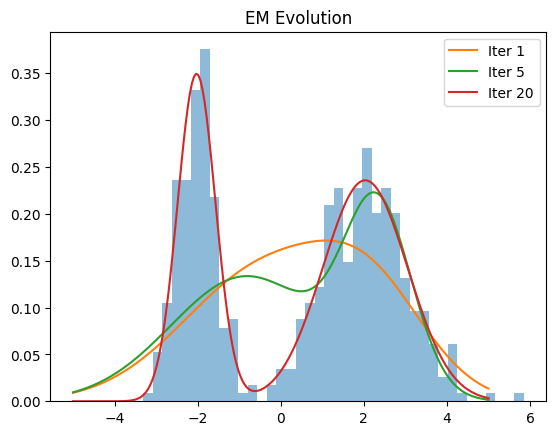

In [26]:
x_vals = np.linspace(-5, 5, 200)

plt.hist(X, bins=40, density=True, alpha=0.5)

for it, (mu_i, sig_i, pi_i) in stored_params.items():
    pdf = sum(pi_i[k] * norm.pdf(x_vals, mu_i[k], np.sqrt(sig_i[k]))
              for k in range(K))
    plt.plot(x_vals, pdf, label=f'Iter {it}')

plt.legend()
plt.title("EM Evolution")
plt.show()